In [409]:
import pandas as pd
import numpy as np
import missingno as msno
from matplotlib import pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.model_selection import train_test_split


In [410]:
df = pd.read_csv('./data/data.csv')

In [411]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

<Axes: >

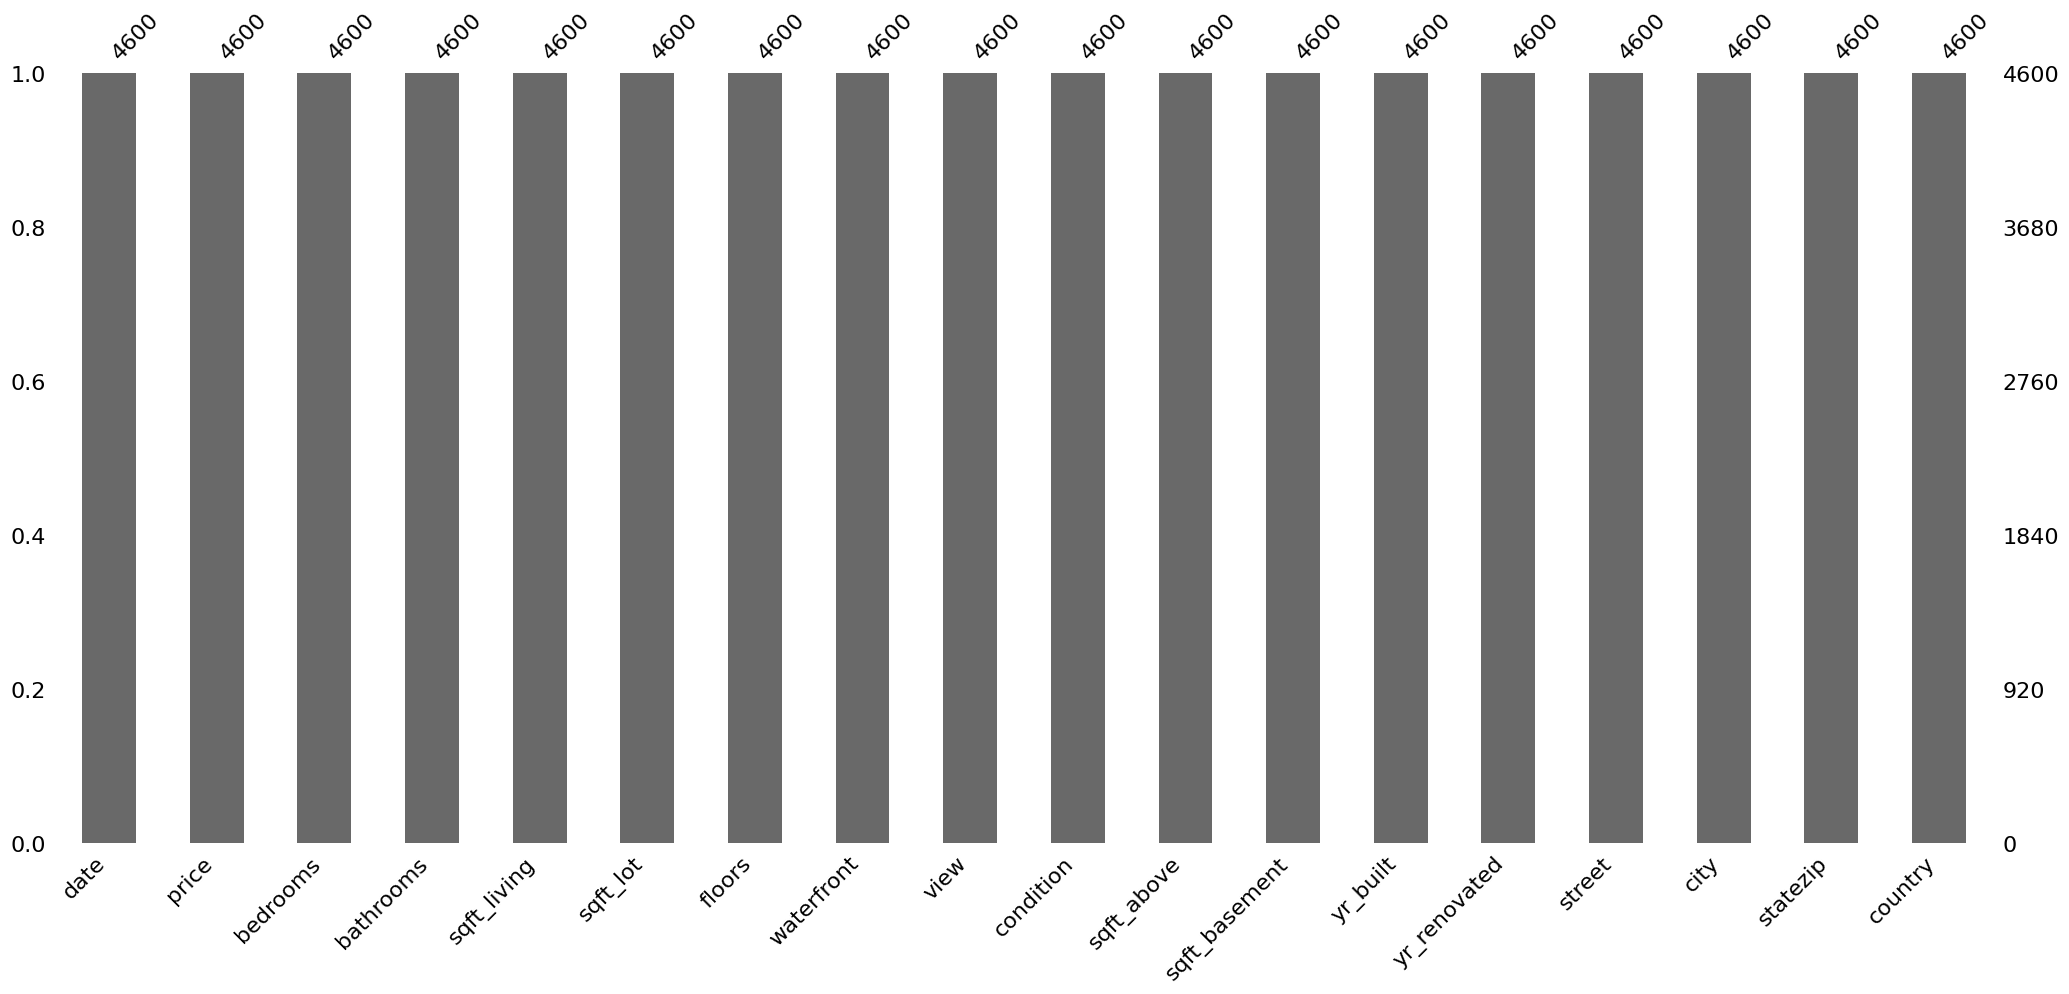

In [412]:
msno.bar(df)

<Axes: >

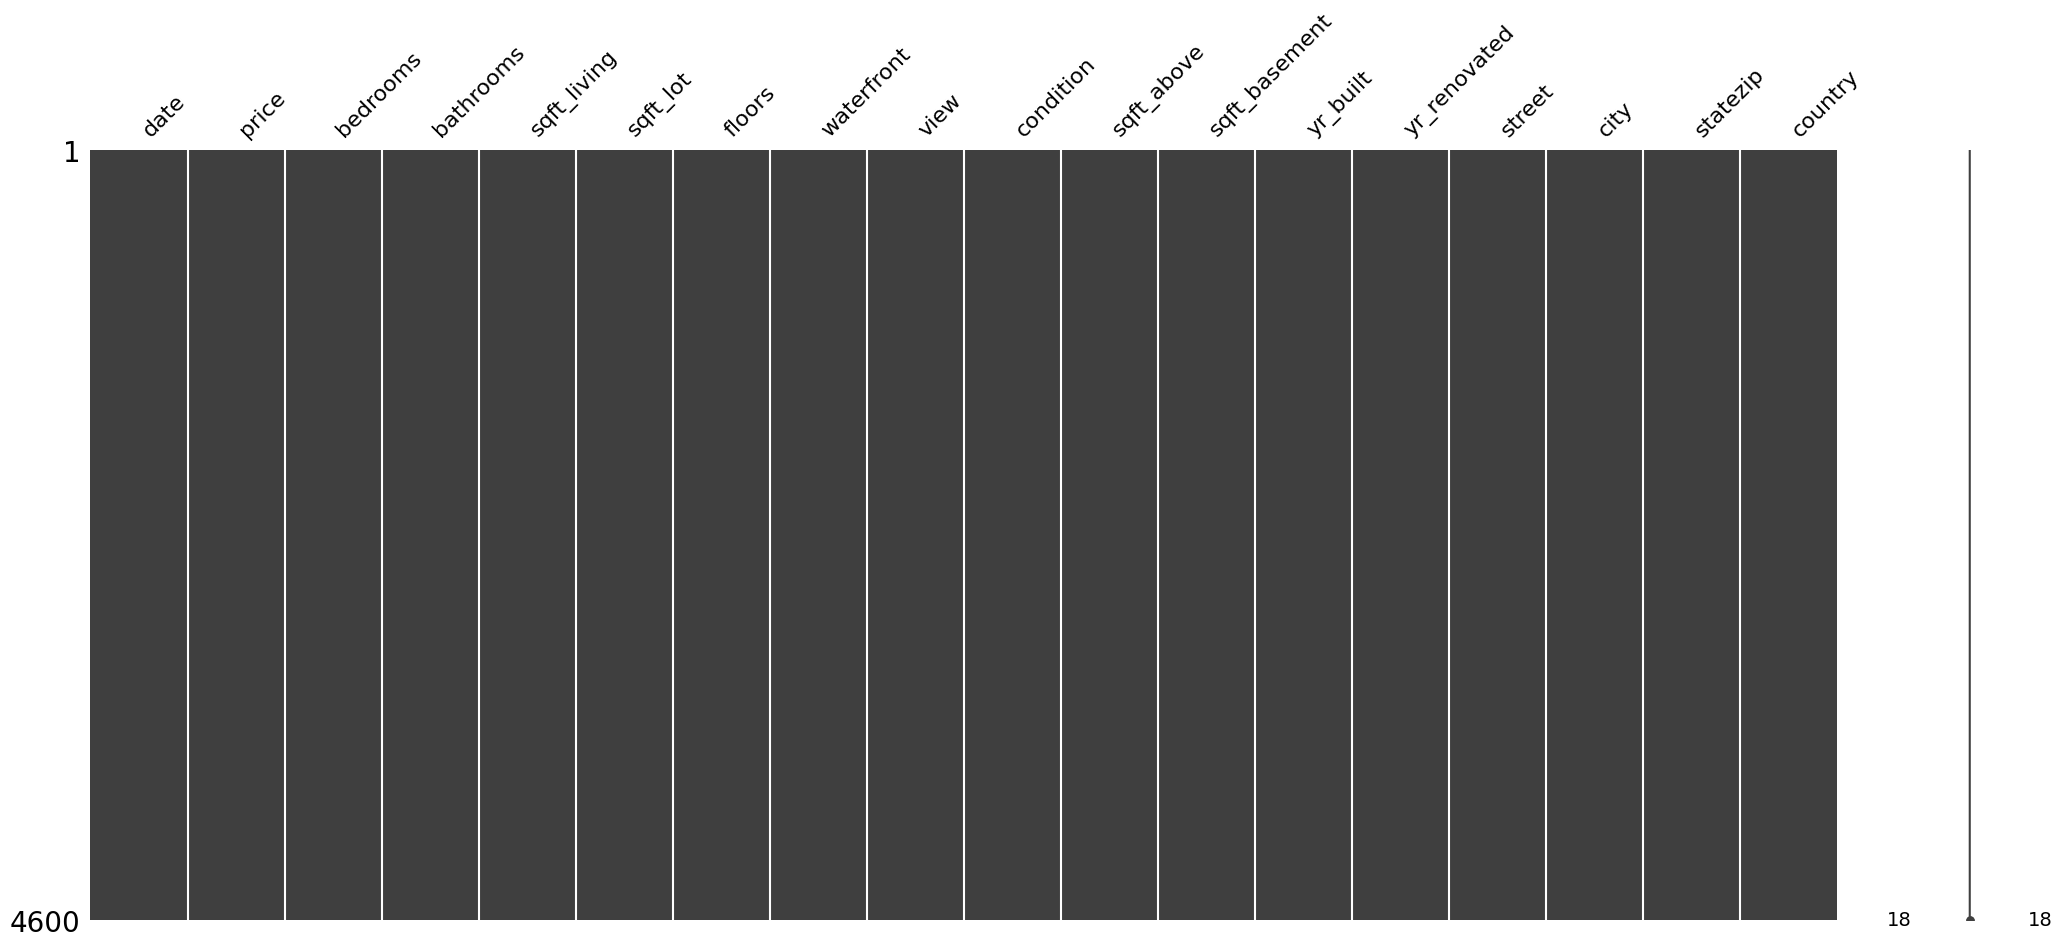

In [413]:
msno.matrix(df)

In [414]:
df['date'].head(5)

0    2014-05-02 00:00:00
1    2014-05-02 00:00:00
2    2014-05-02 00:00:00
3    2014-05-02 00:00:00
4    2014-05-02 00:00:00
Name: date, dtype: str

In [415]:
pd.to_datetime(df['date'])

0      2014-05-02
1      2014-05-02
2      2014-05-02
3      2014-05-02
4      2014-05-02
          ...    
4595   2014-07-09
4596   2014-07-09
4597   2014-07-09
4598   2014-07-10
4599   2014-07-10
Name: date, Length: 4600, dtype: datetime64[us]

In [416]:
df_clean = df.copy()

In [417]:
df_clean['date'] = pd.to_datetime(df['date'])

In [418]:
df_clean = df_clean.drop(columns=['country'])

In [419]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4600 non-null   datetime64[us]
 1   price          4600 non-null   float64       
 2   bedrooms       4600 non-null   float64       
 3   bathrooms      4600 non-null   float64       
 4   sqft_living    4600 non-null   int64         
 5   sqft_lot       4600 non-null   int64         
 6   floors         4600 non-null   float64       
 7   waterfront     4600 non-null   int64         
 8   view           4600 non-null   int64         
 9   condition      4600 non-null   int64         
 10  sqft_above     4600 non-null   int64         
 11  sqft_basement  4600 non-null   int64         
 12  yr_built       4600 non-null   int64         
 13  yr_renovated   4600 non-null   int64         
 14  street         4600 non-null   str           
 15  city           4600 non-null   s

In [420]:
df_clean['statezip'].unique()


<StringArray>
['WA 98133', 'WA 98119', 'WA 98042', 'WA 98008', 'WA 98052', 'WA 98115',
 'WA 98038', 'WA 98045', 'WA 98155', 'WA 98105', 'WA 98074', 'WA 98106',
 'WA 98007', 'WA 98092', 'WA 98198', 'WA 98006', 'WA 98102', 'WA 98011',
 'WA 98125', 'WA 98003', 'WA 98136', 'WA 98033', 'WA 98029', 'WA 98117',
 'WA 98034', 'WA 98072', 'WA 98023', 'WA 98107', 'WA 98166', 'WA 98116',
 'WA 98024', 'WA 98055', 'WA 98077', 'WA 98027', 'WA 98059', 'WA 98075',
 'WA 98014', 'WA 98065', 'WA 98199', 'WA 98053', 'WA 98058', 'WA 98122',
 'WA 98103', 'WA 98112', 'WA 98005', 'WA 98118', 'WA 98177', 'WA 98004',
 'WA 98019', 'WA 98144', 'WA 98168', 'WA 98001', 'WA 98056', 'WA 98146',
 'WA 98028', 'WA 98148', 'WA 98057', 'WA 98040', 'WA 98010', 'WA 98051',
 'WA 98031', 'WA 98109', 'WA 98030', 'WA 98126', 'WA 98032', 'WA 98178',
 'WA 98288', 'WA 98108', 'WA 98070', 'WA 98188', 'WA 98002', 'WA 98039',
 'WA 98022', 'WA 98068', 'WA 98047', 'WA 98050', 'WA 98354']
Length: 77, dtype: str

In [421]:
df_clean['city'].unique()

<StringArray>
[          'Shoreline',             'Seattle',                'Kent',
            'Bellevue',             'Redmond',        'Maple Valley',
          'North Bend',    'Lake Forest Park',           'Sammamish',
              'Auburn',          'Des Moines',             'Bothell',
         'Federal Way',            'Kirkland',            'Issaquah',
         'Woodinville',       'Normandy Park',           'Fall City',
              'Renton',           'Carnation',          'Snoqualmie',
              'Duvall',              'Burien',           'Covington',
 'Inglewood-Finn Hill',             'Kenmore',           'Newcastle',
       'Mercer Island',       'Black Diamond',          'Ravensdale',
          'Clyde Hill',              'Algona',           'Skykomish',
             'Tukwila',              'Vashon',        'Yarrow Point',
              'SeaTac',              'Medina',            'Enumclaw',
     'Snoqualmie Pass',             'Pacific',  'Beaux Arts Village',
      

In [422]:
df['city'].nunique(), df['statezip'].nunique(), df['street'].nunique()

(44, 77, 4525)

In [423]:
df_clean = df_clean.drop(columns=['statezip', 'street'])

In [424]:
onehotencoder = OneHotEncoder()
encoded_city = onehotencoder.fit_transform(X=df_clean['city'].to_frame())
df_encoded_city = pd.DataFrame(encoded_city.toarray(), columns=onehotencoder.get_feature_names_out())

In [425]:
df_clean = pd.concat([df_clean, df_encoded_city], axis=1)
df_clean = df_clean.drop(columns=['city'])

In [426]:
df_clean['date'] = df_clean['date'].dt.year

In [427]:
sold_build_diff = df_clean['date'] - df_clean['yr_built']
df_sold_build_diff = pd.DataFrame(sold_build_diff, columns=['sold_build_diff'])
df_clean = pd.concat([df_clean, df_sold_build_diff], axis=1)

In [428]:
ren_diff = df_clean['date'] - df_clean['yr_renovated']
ren_diff[ren_diff == df_clean['date']] = 0
df_ren_diff = pd.DataFrame(ren_diff, columns=['ren_diff'])
df_clean = pd.concat([df_clean, df_ren_diff], axis=1)

In [429]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 60 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      4600 non-null   int32  
 1   price                     4600 non-null   float64
 2   bedrooms                  4600 non-null   float64
 3   bathrooms                 4600 non-null   float64
 4   sqft_living               4600 non-null   int64  
 5   sqft_lot                  4600 non-null   int64  
 6   floors                    4600 non-null   float64
 7   waterfront                4600 non-null   int64  
 8   view                      4600 non-null   int64  
 9   condition                 4600 non-null   int64  
 10  sqft_above                4600 non-null   int64  
 11  sqft_basement             4600 non-null   int64  
 12  yr_built                  4600 non-null   int64  
 13  yr_renovated              4600 non-null   int64  
 14  city_Algona        

In [430]:
df_clean = df_clean.drop(columns=['date', 'yr_built', 'yr_renovated'])

In [431]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     4600 non-null   float64
 1   bedrooms                  4600 non-null   float64
 2   bathrooms                 4600 non-null   float64
 3   sqft_living               4600 non-null   int64  
 4   sqft_lot                  4600 non-null   int64  
 5   floors                    4600 non-null   float64
 6   waterfront                4600 non-null   int64  
 7   view                      4600 non-null   int64  
 8   condition                 4600 non-null   int64  
 9   sqft_above                4600 non-null   int64  
 10  sqft_basement             4600 non-null   int64  
 11  city_Algona               4600 non-null   float64
 12  city_Auburn               4600 non-null   float64
 13  city_Beaux Arts Village   4600 non-null   float64
 14  city_Bellevue      

In [432]:
df_clean['sqft_living'].head(5), df_clean['sqft_above'].head(5), df_clean['sqft_basement'].head(5)

(0    1340
 1    3650
 2    1930
 3    2000
 4    1940
 Name: sqft_living, dtype: int64,
 0    1340
 1    3370
 2    1930
 3    1000
 4    1140
 Name: sqft_above, dtype: int64,
 0       0
 1     280
 2       0
 3    1000
 4     800
 Name: sqft_basement, dtype: int64)

In [433]:
df_clean[['floors', 'price']].corr()

,floors,price
floors,1.000000,0.151461
price,0.151461,1.000000


In [434]:
df_clean.groupby('floors')['price'].mean()

floors
1.0    457278.687261
1.5    578692.700221
2.0    647985.230123
2.5    983863.390244
3.0    566157.587674
3.5    829250.000000
Name: price, dtype: float64

In [435]:
df_clean.value_counts('floors')

floors
1.0    2174
2.0    1811
1.5     444
3.0     128
2.5      41
3.5       2
Name: count, dtype: int64

In [436]:
df_clean.loc[df_clean['floors'] == 2.5, 'floors'] = 3.0
df_clean.loc[df_clean['floors'] == 3.5, 'floors'] = 3.0

In [437]:
df_clean[['price', 'floors']].corr()

,price,floors
price,1.000000,0.154886
floors,0.154886,1.000000


In [438]:
df_clean['price'].describe()

count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64

<Axes: >

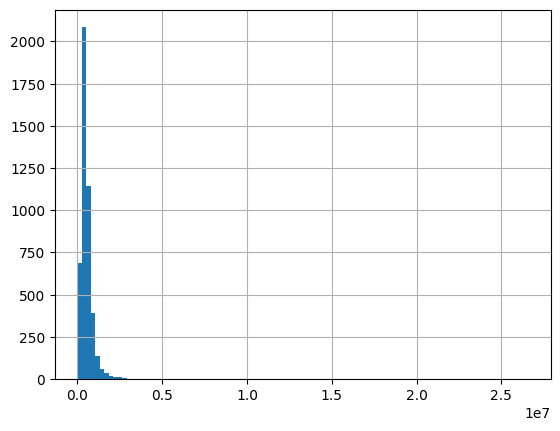

In [439]:
df_clean['price'].hist(bins=100)

{'whiskers': [<matplotlib.lines.Line2D at 0x14bc556d0>,
 'caps': [<matplotlib.lines.Line2D at 0x148df7410>,
 'boxes': [<matplotlib.lines.Line2D at 0x14ec04500>],
 'medians': [<matplotlib.lines.Line2D at 0x148df6a80>],
 'fliers': [<matplotlib.lines.Line2D at 0x148df4c50>],
 'means': []}

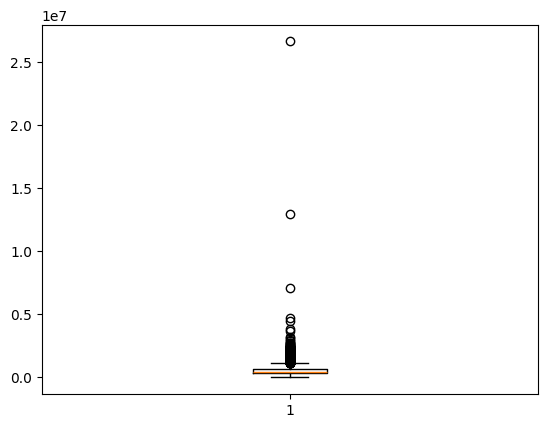

In [440]:
# Let's check with boxplot

plt.boxplot(df_clean['price'])

In [441]:
df_test = df_clean.copy()
df_test['price'] = np.log(df_test['price'])
df_test['price'].describe()

/Users/ibnsaud/Documents/code/ML/Kaggle/House_price_prediction/venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/ibnsaud/Documents/code/ML/Kaggle/House_price_prediction/venv/lib/python3.12/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    4600.000000
mean            -inf
std              NaN
min             -inf
25%        12.685020
50%        13.041031
75%        13.392333
max        17.096046
Name: price, dtype: float64

In [442]:
np.sum(df_clean['price'] == 0)

np.int64(49)

In [443]:
df_clean = df_clean[df_clean['price'] > 0]

In [444]:
df_test = df_clean.copy()
df_test['price'] = np.log(df_test['price'])
df_test['price'].describe()

count    4551.000000
mean       13.064963
std         0.542789
min         8.961879
25%        12.695463
50%        13.049793
75%        13.396200
max        17.096046
Name: price, dtype: float64

<Axes: >

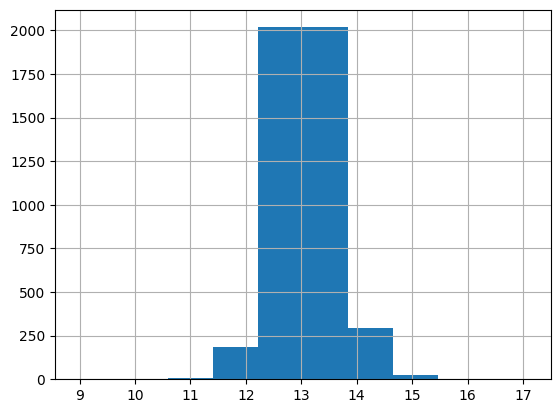

In [445]:
df_test['price'].hist()

Now let's train our baseline model and record the result.

In [446]:

linreg = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(df_test.drop(columns=['price']), df_test['price'], random_state=42)
linreg.fit(X=X_train, y=y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [447]:
y_pred = linreg.predict(X_test)

In [448]:
y_pred = np.exp(y_pred)
y_real = np.exp(y_test)

rmse = np.sqrt(np.mean((y_real - y_pred)**2))
mae = np.mean(np.abs(y_pred - y_real))


In [449]:
errors = np.abs(y_real - y_pred)
sorted(errors)[-5:]

[2026815.5155450632,
 2164085.46505392,
 3916393.2876013797,
 6069635.256010381,
 30486274.065277006]

In [450]:
rmse, mae

(np.float64(949502.0136087707), np.float64(144501.03032456795))

In [451]:
y_train_pred = linreg.predict(X_train)
y_pred = np.exp(y_train_pred)
y_real = np.exp(y_train)
rmse = np.sqrt(np.mean((y_real - y_pred)**2))
mae = np.mean(np.abs(y_pred - y_real))

In [452]:
rmse, mae

(np.float64(539732.8520186201), np.float64(121018.46203450211))

Now i'm trying to improve our model. Lets first remove a lot of binary features for city (from OneHotEncoder) and create new feature with mean house price for this city.

In [453]:
df_test.info()

<class 'pandas.DataFrame'>
Index: 4551 entries, 0 to 4599
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     4551 non-null   float64
 1   bedrooms                  4551 non-null   float64
 2   bathrooms                 4551 non-null   float64
 3   sqft_living               4551 non-null   int64  
 4   sqft_lot                  4551 non-null   int64  
 5   floors                    4551 non-null   float64
 6   waterfront                4551 non-null   int64  
 7   view                      4551 non-null   int64  
 8   condition                 4551 non-null   int64  
 9   sqft_above                4551 non-null   int64  
 10  sqft_basement             4551 non-null   int64  
 11  city_Algona               4551 non-null   float64
 12  city_Auburn               4551 non-null   float64
 13  city_Beaux Arts Village   4551 non-null   float64
 14  city_Bellevue           

In [454]:
city_columns = [column for column in df_test.columns if 'city' in column]
df_test = df_test.drop(columns=city_columns)

In [455]:
df_test['statezip'] = df.loc[df.index, 'statezip']

In [456]:
X_train, X_test, y_train, y_test = train_test_split(df_test.drop(columns=['price']), df_test['price'], random_state=42)

In [457]:
statezip_mean_price = y_train.groupby(X_train['statezip']).mean()
statezip_mean_price = np.log(statezip_mean_price)

In [458]:
X_train['statezip_mean_price'] = X_train['statezip'].map(statezip_mean_price)
X_test['statezip_mean_price'] = X_test['statezip'].map(statezip_mean_price)

In [459]:
X_train = X_train.drop(columns=['statezip'])
X_test = X_test.drop(columns=['statezip'])

In [460]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 3413 entries, 1491 to 860
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   bedrooms             3413 non-null   float64
 1   bathrooms            3413 non-null   float64
 2   sqft_living          3413 non-null   int64  
 3   sqft_lot             3413 non-null   int64  
 4   floors               3413 non-null   float64
 5   waterfront           3413 non-null   int64  
 6   view                 3413 non-null   int64  
 7   condition            3413 non-null   int64  
 8   sqft_above           3413 non-null   int64  
 9   sqft_basement        3413 non-null   int64  
 10  sold_build_diff      3413 non-null   int64  
 11  ren_diff             3413 non-null   int64  
 12  statezip_mean_price  3413 non-null   float64
dtypes: float64(4), int64(9)
memory usage: 373.3 KB


In [461]:
linreg.fit(X=X_train, y=y_train)

y_pred = linreg.predict(X_test)

y_pred = np.exp(y_pred)
y_real = np.exp(y_test)
rmse = np.sqrt(np.mean((y_real - y_pred)**2))

In [462]:
rmse, mae

(np.float64(528793.9335269058), np.float64(121018.46203450211))

In [463]:
errors = np.abs(y_real - y_pred)
sorted(errors)[-5:]

[1896451.965001966,
 1979195.7457038949,
 2257629.9542003833,
 5259299.962809698,
 15817457.837494574]

In [464]:
y_train_pred = linreg.predict(X_train)
y_pred = np.exp(y_train_pred)
y_real = np.exp(y_train)
rmse = np.sqrt(np.mean((y_real - y_pred)**2))
mae = np.mean(np.abs(y_pred - y_real))

In [465]:
rmse, mae

(np.float64(528743.9405472304), np.float64(107198.56543416716))

Now let's apply StandardScaler to all numeric features.

In [466]:
df_test.info()

<class 'pandas.DataFrame'>
Index: 4551 entries, 0 to 4599
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            4551 non-null   float64
 1   bedrooms         4551 non-null   float64
 2   bathrooms        4551 non-null   float64
 3   sqft_living      4551 non-null   int64  
 4   sqft_lot         4551 non-null   int64  
 5   floors           4551 non-null   float64
 6   waterfront       4551 non-null   int64  
 7   view             4551 non-null   int64  
 8   condition        4551 non-null   int64  
 9   sqft_above       4551 non-null   int64  
 10  sqft_basement    4551 non-null   int64  
 11  sold_build_diff  4551 non-null   int64  
 12  ren_diff         4551 non-null   int64  
 13  statezip         4551 non-null   str    
dtypes: float64(4), int64(9), str(1)
memory usage: 533.3 KB


In [467]:
standard_scaler = StandardScaler()
numeric_columns = [
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'floors',
    'view',
    'condition',
    'sqft_above',
    'sqft_basement',
    'sold_build_diff',
    'ren_diff',
    'statezip_mean_price',
    ]
X_test[numeric_columns] = standard_scaler.fit_transform(X_test[numeric_columns])
X_train[numeric_columns] = standard_scaler.fit_transform(X_train[numeric_columns])

In [468]:
df_test.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,sold_build_diff,ren_diff
count,4551.000000,4551.000000,4551.000000,4551.000000,4.551000e+03,4551.000000,4551.000000,4551.000000,4551.000000,4551.000000,4551.000000,4551.000000,4551.000000
mean,13.064963,3.394639,2.155021,2132.372226,1.483528e+04,1.516480,0.006592,0.234674,3.449352,1822.221710,310.150516,43.204351,7.922435
std,0.542789,0.904595,0.776351,955.949708,3.596408e+04,0.548076,0.080932,0.765373,0.675160,854.452888,461.987629,29.760073,16.630474
min,8.961879,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,0.000000,0.000000
25%,12.695463,3.000000,1.750000,1460.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,17.000000,0.000000
50%,13.049793,3.000000,2.250000,1970.000000,7.680000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,38.000000,0.000000
75%,13.396200,4.000000,2.500000,2610.000000,1.097800e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,600.000000,63.000000,11.000000
max,17.096046,9.000000,8.000000,13540.000000,1.074218e+06,3.000000,1.000000,4.000000,5.000000,9410.000000,4820.000000,114.000000,102.000000


In [469]:
linreg.fit(X=X_train, y=y_train)

y_pred = linreg.predict(X_test)

y_pred = np.exp(y_pred)
y_real = np.exp(y_test)
rmse = np.sqrt(np.mean((y_real - y_pred)**2))

In [470]:
rmse

np.float64(399531.0372716284)

In [471]:
linreg.coef_

array([-0.01623477,  0.06030386,  0.11801314, -0.00449961,  0.02500268,
        0.1579746 ,  0.05893298,  0.03639398,  0.1093858 ,  0.03877931,
        0.04503429,  0.01302832,  0.29601362])

In [472]:
df_test.info()

<class 'pandas.DataFrame'>
Index: 4551 entries, 0 to 4599
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            4551 non-null   float64
 1   bedrooms         4551 non-null   float64
 2   bathrooms        4551 non-null   float64
 3   sqft_living      4551 non-null   int64  
 4   sqft_lot         4551 non-null   int64  
 5   floors           4551 non-null   float64
 6   waterfront       4551 non-null   int64  
 7   view             4551 non-null   int64  
 8   condition        4551 non-null   int64  
 9   sqft_above       4551 non-null   int64  
 10  sqft_basement    4551 non-null   int64  
 11  sold_build_diff  4551 non-null   int64  
 12  ren_diff         4551 non-null   int64  
 13  statezip         4551 non-null   str    
dtypes: float64(4), int64(9), str(1)
memory usage: 533.3 KB


Now let's imporve model with Lasso and Ridge regularization.

In [473]:
linreg_lasso = Lasso(alpha=0.05)
# 1.0: underfitting 
# 0.1: rmse = 248,828
# 0.05: rmse = 321,513
# 0.01: rmse = 486,207


In [474]:
linreg_lasso.fit(X_train, y_train)

y_pred = linreg_lasso.predict(X_test)

y_pred = np.exp(y_pred)
y_real = np.exp(y_test)
rmse = np.sqrt(np.mean((y_real - y_pred)**2))
mae = np.mean(np.abs(y_pred - y_real))

In [475]:
rmse

np.float64(260691.6307523585)

In [476]:
mae

np.float64(116674.83907555795)

In [477]:
linreg_lasso.coef_

array([0.        , 0.00961636, 0.21714973, 0.        , 0.        ,
       0.        , 0.02966941, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.27255237])

In [478]:
np.mean(y_train)

np.float64(13.061645015545537)

In [479]:
df['price'].describe()

count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64

Let's apply Decision Tree Regressor for House price prediction dataset and compare with Linear regression

In [480]:
decistion_tree = DecisionTreeRegressor(criterion='squared_error', max_depth=5)
# max_depth = 5: mae=123,471
# max_depth = 10: mae=132,204 - overfitting

In [481]:
decistion_tree.fit(X=X_train, y=y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [482]:
y_pred = decistion_tree.predict(X_test)
y_pred = np.exp(y_pred)
y_real = np.exp(y_test)

In [483]:
rmse = np.sqrt(np.mean((y_real - y_pred)**2))
rmse

np.float64(247166.77308760607)

In [484]:
mae = np.mean(np.abs(y_pred - y_real))
mae

np.float64(123471.82496537865)

In [485]:
y_train_pred = decistion_tree.predict(X_train)
y_pred = np.exp(y_train_pred)
y_real = np.exp(y_train)

In [486]:
rmse = np.sqrt(np.mean((y_real - y_pred)**2))
rmse

np.float64(524059.58945104433)

In [487]:
mae = np.mean(np.abs(y_pred - y_real))
mae

np.float64(112309.93222153376)

In [488]:
tree_rules = export_text(decistion_tree, feature_names=list(X_test.columns))
print(tree_rules)

|--- statezip_mean_price <= -0.12
|   |--- sqft_living <= 0.10
|   |   |--- statezip_mean_price <= -1.12
|   |   |   |--- condition <= -2.88
|   |   |   |   |--- value: [8.96]
|   |   |   |--- condition >  -2.88
|   |   |   |   |--- sqft_living <= -0.80
|   |   |   |   |   |--- value: [12.20]
|   |   |   |   |--- sqft_living >  -0.80
|   |   |   |   |   |--- value: [12.49]
|   |   |--- statezip_mean_price >  -1.12
|   |   |   |--- sqft_living <= -0.72
|   |   |   |   |--- condition <= -1.40
|   |   |   |   |   |--- value: [11.96]
|   |   |   |   |--- condition >  -1.40
|   |   |   |   |   |--- value: [12.55]
|   |   |   |--- sqft_living >  -0.72
|   |   |   |   |--- statezip_mean_price <= -0.78
|   |   |   |   |   |--- value: [12.64]
|   |   |   |   |--- statezip_mean_price >  -0.78
|   |   |   |   |   |--- value: [12.90]
|   |--- sqft_living >  0.10
|   |   |--- sqft_living <= 1.11
|   |   |   |--- statezip_mean_price <= -0.78
|   |   |   |   |--- view <= 1.71
|   |   |   |   |   |---

In [489]:
X_train['statezip_mean_price'].describe()

count    3.413000e+03
mean     1.045256e-14
std      1.000147e+00
min     -2.199830e+00
25%     -9.019706e-01
50%      1.624792e-01
75%      6.691082e-01
max      3.144463e+00
Name: statezip_mean_price, dtype: float64

In [490]:
X_train['sqft_living'].describe()

count    3.413000e+03
mean    -2.040234e-16
std      1.000147e+00
min     -1.869621e+00
25%     -7.106974e-01
50%     -1.526973e-01
75%      5.018797e-01
max      8.496304e+00
Name: sqft_living, dtype: float64

In [491]:
importances = pd.Series(
    decistion_tree.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances)

statezip_mean_price    0.607804
sqft_living            0.355436
condition              0.018546
view                   0.015207
sqft_lot               0.003008
bedrooms               0.000000
bathrooms              0.000000
floors                 0.000000
waterfront             0.000000
sqft_above             0.000000
sqft_basement          0.000000
sold_build_diff        0.000000
ren_diff               0.000000
dtype: float64


<Axes: >

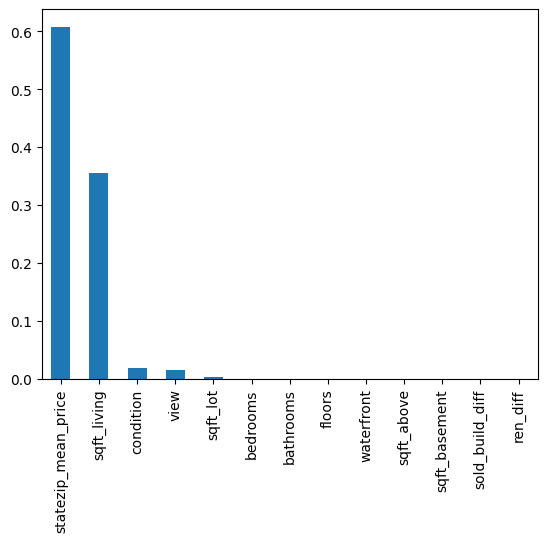

In [492]:
importances.plot(kind='bar')

Let's test dataset with only two features: statezip_mean_price and sqft_living.

In [493]:
important_features = ['sqft_living', 'statezip_mean_price']
X_two_features_test, X_two_features_train = X_test[important_features], X_train[important_features]

In [494]:
linreg.fit(X=X_two_features_train, y=y_train)
y_pred = linreg.predict(X_two_features_test)

y_pred = np.exp(y_pred)
y_real = np.exp(y_test)
rmse = np.sqrt(np.mean((y_real - y_pred)**2))
mae = np.mean(np.abs(y_pred - y_real))

In [495]:
rmse, mae

(np.float64(354986.1119082023), np.float64(120035.06879308338))

In [496]:
decistion_tree = DecisionTreeRegressor(criterion='squared_error', max_depth=5)
decistion_tree.fit(X=X_two_features_train, y=y_train)

y_pred = decistion_tree.predict(X_two_features_test)

y_pred = np.exp(y_pred)
y_real = np.exp(y_test)
rmse = np.sqrt(np.mean((y_real - y_pred)**2))
mae = np.mean(np.abs(y_pred - y_real))

In [497]:
rmse, mae

(np.float64(232150.92266641432), np.float64(120010.69605508748))

Let's add complex feature statezip_mean_price * sqft_living

In [498]:
X_test['statezip_sqft'] = X_test['sqft_living'] * X_test['statezip_mean_price']
X_train['statezip_sqft'] = X_train['sqft_living'] * X_train['statezip_mean_price']
X_test['statezip_sqft'] = standard_scaler.fit_transform(X_test[['statezip_sqft']])
X_train['statezip_sqft'] = standard_scaler.fit_transform(X_train[['statezip_sqft']])

In [499]:
linreg.fit(X=X_two_features_train, y=y_train)
y_pred = linreg.predict(X_two_features_test)

y_pred = np.exp(y_pred)
y_real = np.exp(y_test)
rmse = np.sqrt(np.mean((y_real - y_pred)**2))
mae = np.mean(np.abs(y_pred - y_real))

In [500]:
rmse, mae

(np.float64(354986.1119082023), np.float64(120035.06879308338))

Let's create a pipeline for data preparation

In [501]:
def process_data_pipeline(df: pd.DataFrame, target_quantile: float = None):
    df_clean = df.copy()
    df_clean = df_clean[df_clean['price'] > 0]
    df_clean['price'] = np.log(df_clean['price'])
    
    if target_quantile is not None:
        threshold = df_clean['price'].quantile(target_quantile)
        df_clean = df_clean.drop(df_clean[df_clean['price'] > threshold].index)
        
    
    df_clean['date'] = pd.to_datetime(df['date']).dt.year
    df_clean = df_clean.drop(columns=['country', 'street', 'city'])
    
    sold_build_diff = df_clean['date'] - df_clean['yr_built']
    df_sold_build_diff = pd.DataFrame(sold_build_diff, columns=['sold_build_diff'])
    df_clean = pd.concat([df_clean, df_sold_build_diff], axis=1)
    
    ren_diff = df_clean['date'] - df_clean['yr_renovated']
    ren_diff[ren_diff == df_clean['date']] = 0
    df_ren_diff = pd.DataFrame(ren_diff, columns=['ren_diff'])
    df_clean = pd.concat([df_clean, df_ren_diff], axis=1)
    
    df_clean = df_clean.drop(columns=['date', 'yr_built', 'yr_renovated'])
    
    df_clean.loc[df_clean['floors'] == 2.5, 'floors'] = 3.0
    df_clean.loc[df_clean['floors'] == 3.5, 'floors'] = 3.0
    
    X_train, X_test, y_train, y_test = train_test_split(df_clean.drop(columns=['price']), df_clean['price'], random_state=42)
    statezip_mean_price = y_train.groupby(X_train['statezip']).mean()
    X_train['statezip_mean_price'] = X_train['statezip'].map(statezip_mean_price).fillna(y_train.mean())
    X_test['statezip_mean_price'] = X_test['statezip'].map(statezip_mean_price).fillna(y_train.mean())
    
    X_train = X_train.drop(columns=['statezip'])
    X_test = X_test.drop(columns=['statezip'])
    
    standard_scaler = StandardScaler()
    numeric_columns = [
        'bedrooms',
        'bathrooms',
        'sqft_living',
        'sqft_lot',
        'floors',
        'view',
        'condition',
        'sqft_above',
        'sqft_basement',
        'sold_build_diff',
        'ren_diff',
        'statezip_mean_price',
        ]
    
    X_train[numeric_columns] = standard_scaler.fit_transform(X_train[numeric_columns])
    X_test[numeric_columns] = standard_scaler.transform(X_test[numeric_columns])
    
    return X_train, y_train, X_test, y_test

In [502]:
X_train, y_train, X_test, y_test = process_data_pipeline(df)

lasso_reg = Lasso(alpha=0.05)
lasso_reg.fit(X_train, y_train)

y_pred = lasso_reg.predict(X_test)
y_pred = np.exp(y_pred)
y_real = np.exp(y_test)
rmse = np.sqrt(np.mean((y_real - y_pred)**2))
mae = np.mean(np.abs(y_pred - y_real))

In [503]:
df['price'].mean(), rmse, mae

(np.float64(551962.9884732141),
 np.float64(308856.2376845701),
 np.float64(117024.4340729773))

Let's remove houses with prices > 0.99 quantile

In [504]:
y_train.quantile(q=0.5), y_train.quantile(q=0.99)

(np.float64(13.047639831208393), np.float64(14.52075788862878))

In [505]:
X_train, y_train, X_test, y_test = process_data_pipeline(df, target_quantile=0.99)
lasso_reg = Lasso(alpha=0.05)
lasso_reg.fit(X_train, y_train)

y_pred = lasso_reg.predict(X_test)
y_pred = np.exp(y_pred)
y_real = np.exp(y_test)
rmse = np.sqrt(np.mean((y_real - y_pred)**2))
mae = np.mean(np.abs(y_pred - y_real))

In [506]:
df['price'].mean(), rmse, mae

(np.float64(551962.9884732141),
 np.float64(156646.82610581256),
 np.float64(98446.86058311004))